In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
games = pd.read_csv(r"C:\Users\usuario1\Documents\games.csv")


games.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [3]:
games.columns =  games.columns.str.lower()

games["user_score"] = games["user_score"].replace("tbd", np.nan)
games["user_score"] = games["user_score"].astype(float)
games["critic_score"] = games["critic_score"].replace("tbd", np.nan)
games["year_of_release"] = pd.to_numeric(games["year_of_release"], errors = "coerce").astype("Int64")
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


aqui cambie el user_score a float ya que son numeros con decimales y sera dificil continuar si esta como object, asi como cambie year of release por que son años y un año simpre debe de estar entero 

In [4]:
games["rating"] = games["rating"].fillna("indefinido")
games["name"]= games["name"].fillna("")
games["year_of_release"] = games["year_of_release"].fillna(2016)
games["total_sales"] = games["na_sales"]+games["eu_sales"]+ games["jp_sales"]+ games["other_sales"]


aqui en la columna year_of_release rellene los datos ausentes con el año 2016 por que en el 2016 faltan datos, y aparte por que asi no me afectan tanto en la cuestion de los graficos que se me píden

3 . ANALISIS DE LOS DATOS 

In [5]:
games["year_of_release"].value_counts()

year_of_release
2008    1427
2009    1426
2010    1255
2007    1197
2011    1136
2006    1006
2005     939
2002     829
2003     775
2016     771
2004     762
2012     653
2015     606
2014     581
2013     544
2001     482
1998     379
2000     350
1999     338
1997     289
1996     263
1995     219
1994     121
1993      62
1981      46
1992      43
1991      41
1982      36
1986      21
1989      17
1983      17
1987      16
1990      16
1988      15
1985      14
1984      14
1980       9
Name: count, dtype: Int64

los datos nos demuestran que del 2006 al 2011 fueron los años en los que mas juegos fueron lanzados, mostrando  una baja significativa en lanzamiento de juegos de los  años 2012 en adelante 

In [6]:
ventas_plataformas = games.groupby(["platform","year_of_release"])["total_sales"].sum().reset_index()
mejores_plataformas  = (ventas_plataformas.groupby("platform")["total_sales"].sum().sort_values(ascending = False).head(5).index)
print(ventas_plataformas, "y la 5 mejores plataformas son :", mejores_plataformas)

    platform  year_of_release  total_sales
0       2600             1980        11.38
1       2600             1981        35.68
2       2600             1982        28.88
3       2600             1983         5.84
4       2600             1984         0.27
..       ...              ...          ...
243       XB             2016         6.17
244     XOne             2013        18.96
245     XOne             2014        54.07
246     XOne             2015        60.14
247     XOne             2016        26.15

[248 rows x 3 columns] y la 5 mejores plataformas son : Index(['PS2', 'X360', 'PS3', 'Wii', 'DS'], dtype='object', name='platform')


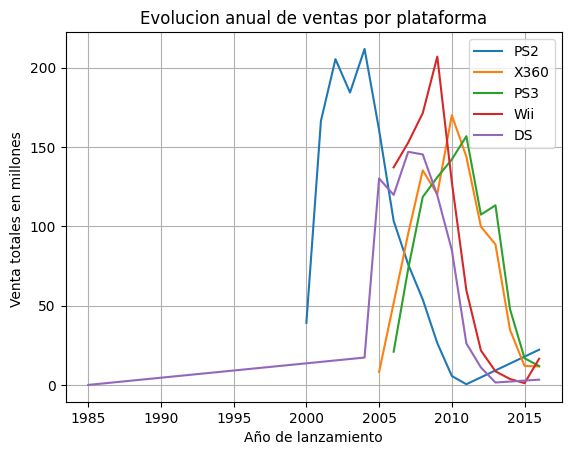

In [7]:
datos_plat = ventas_plataformas[ventas_plataformas["platform"].isin(mejores_plataformas)]
for plataforma in mejores_plataformas:
    datos = datos_plat[datos_plat["platform"]== plataforma]
    plt.plot(datos["year_of_release"], datos["total_sales"], label = plataforma)
plt.title ("Evolucion anual de ventas por plataforma")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Venta totales en millones ")
plt.legend()
plt.grid(True)
plt.show()
    

In [8]:
ultima_venta = ventas_plataformas.groupby("platform")["year_of_release"].max().reset_index()
plataformas_inactiva = ultima_venta[ultima_venta["year_of_release"] < 2015]
print(plataformas_inactiva)

   platform  year_of_release
1       3DO             1995
3        DC             2008
8       GEN             1994
9        GG             1992
11      NES             1994
12       NG             1996
14     PCFX             1996
21      SAT             1999
22      SCD             1994
23     SNES             1999
24     TG16             1995
25       WS             2001


In [9]:
vida_plataformas = (ventas_plataformas.groupby("platform")["year_of_release"].agg(["min", "max"]) .assign(duracion = lambda x : x["max"]- x ["min"]).sort_values("duracion", ascending = False))
print(vida_plataformas)

           min   max  duracion
platform                      
2600      1980  2016        36
DS        1985  2016        31
PC        1985  2016        31
GB        1988  2016        28
PS        1994  2016        22
N64       1996  2016        20
GBA       2000  2016        16
PS2       2000  2016        16
XB        2000  2016        16
GC        2001  2016        15
PSP       2004  2016        12
NES       1983  1994        11
X360      2005  2016        11
Wii       2006  2016        10
DC        1998  2008        10
PS3       2006  2016        10
SNES      1990  1999         9
PSV       2011  2016         5
SAT       1994  1999         5
3DS       2011  2016         5
GEN       1990  1994         4
WiiU      2012  2016         4
NG        1993  1996         3
XOne      2013  2016         3
PS4       2013  2016         3
WS        1999  2001         2
3DO       1994  1995         1
SCD       1993  1994         1
GG        1992  1992         0
PCFX      1996  1996         0
TG16    

tal como se puede ver las plataformas modernas tienden a durar 10 años en tanto al tiempo en que aparece una nueva version de las mismas

In [10]:
ultimo_año =int(games["year_of_release"].max())
ultimos_años = [ultimo_año-3, ultimo_año-2, ultimo_año-1]
datos_necesarios = games[games["year_of_release"].isin(ultimos_años)]
print(datos_necesarios.head(20))

                                          name platform  year_of_release  \
16                          Grand Theft Auto V      PS3             2013   
23                          Grand Theft Auto V     X360             2013   
31                   Call of Duty: Black Ops 3      PS4             2015   
33                         Pokemon X/Pokemon Y      3DS             2013   
42                          Grand Theft Auto V      PS4             2014   
47   Pokemon Omega Ruby/Pokemon Alpha Sapphire      3DS             2014   
60                        Call of Duty: Ghosts     X360             2013   
69                        Call of Duty: Ghosts      PS3             2013   
72                                   Minecraft     X360             2013   
77                                     FIFA 16      PS4             2015   
87                Star Wars Battlefront (2015)      PS4             2015   
92              Call of Duty: Advanced Warfare      PS4             2014   
96         S

aqui tome la desicion de usar los años 2015, 2014, 2013, ya que en el año 2013 fue cuando salieron los nuevos modelos de las consolas mas populares(XboxOne y PS4), y esto hace que con los datos de estos tres años pueda crear un modelo para el 2017 mas preciso.

In [11]:
mas_vende = (datos_necesarios.groupby("platform")["total_sales"].sum().sort_values(ascending=False))
print(mas_vende)


platform
PS4     244.89
PS3     177.83
X360    135.28
XOne    133.17
3DS     128.11
WiiU     60.03
PC       34.18
PSV      28.74
Wii      13.48
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64


In [12]:
tabla = datos_necesarios.groupby(["platform","year_of_release"])["total_sales"].sum().unstack(fill_value = 0)
print(tabla)

year_of_release    2013    2014    2015
platform                               
3DS               56.57   43.76   27.78
DS                 1.54    0.00    0.00
PC                12.38   13.28    8.52
PS3              113.25   47.76   16.82
PS4               25.99  100.00  118.90
PSP                3.14    0.24    0.12
PSV               10.59   11.90    6.25
Wii                8.59    3.75    1.14
WiiU              21.65   22.03   16.35
X360              88.58   34.74   11.96
XOne              18.96   54.07   60.14


In [13]:
def tendencia (x) :
    y = x.values.astype(float)
    t = np.arange (len(y))
    slope = np.polyfit(t,y,1)[0]
    cagr = ((y[-1]/ max(y[0], 1e-9))**(1/2))-1
    yoy_last = (y[-1]- y[-2])/max(y[-2],1e-9)
    total = y.sum()
    return pd.Series({"slope":slope, "cagr":cagr, "yoy_last":yoy_last, "total_final":total})

tend= tabla.apply(tendencia, axis = 1)

In [14]:
def clasificacion (fila, thr_slope = 0 , thr_total = None) :
    if thr_total is None :
        thr_total = tend ["total_final"].median()
    if fila["slope"]> thr_slope and fila ["total_final"] >= thr_total :
        return "Creciente"
    if fila["slope"]< - thr_slope and fila[

"total_final"] >= thr_total :
        return "Decreciente"
    return "Estable"

tend["Clasificacion "] = tend.apply(clasificacion, axis= 1)


In [15]:
lideres = tend.sort_values("total_final", ascending = False).head(20)
print(lideres)

           slope      cagr  yoy_last  total_final Clasificacion 
platform                                                        
PS4       46.455  1.138887  0.189000       244.89      Creciente
PS3      -48.215 -0.614616 -0.647822       177.83    Decreciente
X360     -38.310 -0.632550 -0.655728       135.28    Decreciente
XOne      20.590  0.780994  0.112262       133.17      Creciente
3DS      -14.395 -0.299234 -0.365174       128.11    Decreciente
WiiU      -2.650 -0.130980 -0.257830        60.03    Decreciente
PC        -1.930 -0.170418 -0.358434        34.18        Estable
PSV       -2.170 -0.231769 -0.474790        28.74        Estable
Wii       -3.725 -0.635703 -0.696000        13.48        Estable
PSP       -1.510 -0.804509 -0.500000         3.50        Estable
DS        -0.770 -1.000000  0.000000         1.54        Estable


In [16]:
p55 = tend["total_final"].quantile(0.55)
candidatas_potenciales = (tend[(tend["total_final"]>= p55) & (tend["slope"] > 0) & (tend["cagr"])> 0 ].sort_values(["slope","total_final"],ascending = False))
print(candidatas_potenciales)

           slope      cagr  yoy_last  total_final Clasificacion 
platform                                                        
PS4       46.455  1.138887  0.189000       244.89      Creciente
XOne      20.590  0.780994  0.112262       133.17      Creciente


con estos datos podemos observar que las dos plataformas con mas potencial para el futuro son la PS4  y el Xbox one, ya que son las unicas con una pendiente positiva , al ser la nueva generacion de los dos lideres en consolas, son las mas rentables ya que ya tienen una base solida de clientes fieles a la marca, y que buscaran comprar la nueva generacion de sus consolas favoritas, haciendo que en un futuro tal como marca aqui, las consolas se vuelvan todavia mas rentables, al volverse obsoletas sus predecesoras.

In [17]:
decrecientes = tend[(tend["slope"]< 0) & (tend["cagr"] < 0) ]
peores = decrecientes.sort_values("slope").head(10)
print(peores)

           slope      cagr  yoy_last  total_final Clasificacion 
platform                                                        
PS3      -48.215 -0.614616 -0.647822       177.83    Decreciente
X360     -38.310 -0.632550 -0.655728       135.28    Decreciente
3DS      -14.395 -0.299234 -0.365174       128.11    Decreciente
Wii       -3.725 -0.635703 -0.696000        13.48        Estable
WiiU      -2.650 -0.130980 -0.257830        60.03    Decreciente
PSV       -2.170 -0.231769 -0.474790        28.74        Estable
PC        -1.930 -0.170418 -0.358434        34.18        Estable
PSP       -1.510 -0.804509 -0.500000         3.50        Estable
DS        -0.770 -1.000000  0.000000         1.54        Estable


tal como podeos observar, las consolas que mas han decrecido en los ultimosaños son las consolas PS3 y X360, el por que es la misma situacion ya antes planteada, estas consolas estan decreciendo por que ya salio una generacion mas nueva de la marca, los clinetes fieles, se estan comprando las nuevas generaciones de consolas, asi con el paso del tiempo se volveran obsoleras, ya que en un strascurso de solo 3  años han decrecido significativamete.

<Figure size 1200x600 with 0 Axes>

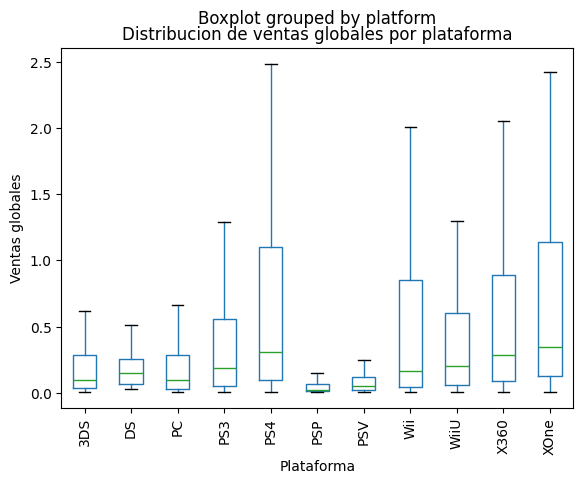

In [18]:
plt.figure(figsize =(12,6))
datos_necesarios.boxplot(column = "total_sales", by = "platform", grid = False, showfliers = False)
plt.title("Distribucion de ventas globales por plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Ventas globales")
plt.xticks (rotation = 90)
plt.show()



A partir del diagrama de caja se observan diferencias significativas entre el volumen de ventas globales  , las consolas de sobremesa tal como XBOX ONE, XBOX360, PS3, PS4 , Wii y WiiU muestran medianas de ventas muy superiores asi como una dispersion amplia, lo que indica que son mercados grandes con titulos considerados como superventas, en contraste con las consolas portatiles tales como 3DS, DS, PSP y  PSV que presentan medianas cercanas a cero y cajas mucho mas compactas , reflejando un volumen de ventas bajo y relativamente estable , con escaos casos atipicos de altas ventas.

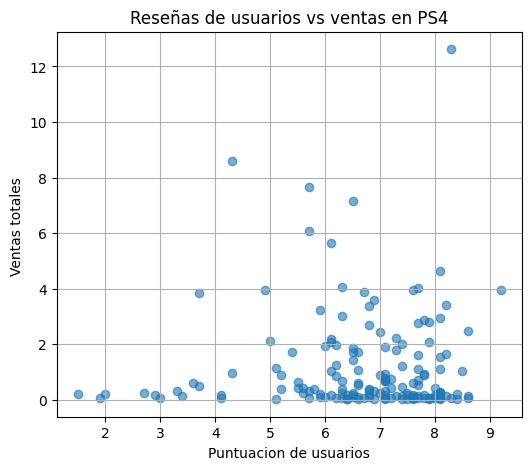

In [19]:
plat_usada = datos_necesarios[datos_necesarios["platform"] == "PS4"].copy()

plt.figure(figsize = (6,5))
plt.scatter(plat_usada["user_score"], plat_usada["total_sales"], alpha = 0.6)
plt.title ("Reseñas de usuarios vs ventas en PS4")
plt.xlabel("Puntuacion de usuarios")
plt.ylabel("Ventas totales ")
plt.grid(True)
plt.show()
           

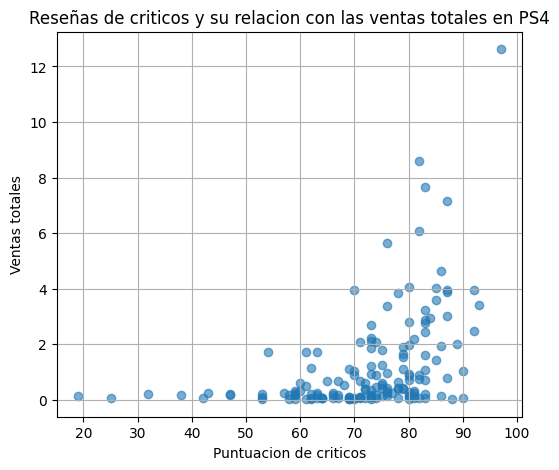

In [20]:
plt.figure(figsize = (6,5))
plt.scatter (plat_usada["critic_score"], plat_usada["total_sales"], alpha = 0.6)
plt.title("Reseñas de criticos y su relacion con las ventas totales en PS4")
plt.xlabel("Puntuacion de criticos")
plt.ylabel("Ventas totales")
plt.grid(True)
plt.show()

In [21]:
correlacion_user = plat_usada["user_score"].corr(plat_usada["total_sales"])
correlacion_criticos = plat_usada["critic_score"].corr(plat_usada["total_sales"])

print("la correacion de  la puntuacion del usuario y las ventas es de :", correlacion_user)
print("la correrlacion de la puntuacion de los criticos y de las ventas es de : ", correlacion_criticos)

la correacion de  la puntuacion del usuario y las ventas es de : 0.024230832360622557
la correrlacion de la puntuacion de los criticos y de las ventas es de :  0.4318482049982005


viendo los resultados de la correlacion entre las ventas y la puntuacion de los usuarios, podemos decir, que no influye en casi nada la puntuacion del usuario con las ventas, mientras que la de los criticos influyen mas en la relaciona  las ventas de los juegos 

In [22]:
juegos_ps4 = plat_usada["name"].unique()

mismos_juegos = datos_necesarios[datos_necesarios["name"].isin(juegos_ps4)].copy()

multiplataforma= mismos_juegos.groupby("name")["platform"].nunique().sort_values(ascending=False )

print(mismos_juegos.head(20))

                               name platform  year_of_release         genre  \
16               Grand Theft Auto V      PS3             2013        Action   
23               Grand Theft Auto V     X360             2013        Action   
31        Call of Duty: Black Ops 3      PS4             2015       Shooter   
42               Grand Theft Auto V      PS4             2014        Action   
60             Call of Duty: Ghosts     X360             2013       Shooter   
69             Call of Duty: Ghosts      PS3             2013       Shooter   
72                        Minecraft     X360             2013          Misc   
77                          FIFA 16      PS4             2015        Sports   
87     Star Wars Battlefront (2015)      PS4             2015       Shooter   
92   Call of Duty: Advanced Warfare      PS4             2014       Shooter   
99        Call of Duty: Black Ops 3     XOne             2015       Shooter   
105                       Fallout 4      PS4        

In [23]:
tab_comparacion = mismos_juegos.pivot_table(index = "name", columns = "platform", values = "total_sales", aggfunc = "sum")
tab_comparacion ["total_sales"]= tab_comparacion.sum(axis = 1)
tab_comparacion = tab_comparacion.sort_values("total_sales", ascending = False)
tab_comparacion.head(20)

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne,total_sales
name,,,,,,,,,,,,
Grand Theft Auto V,NaN,NaN,1.17,21.05,12.62,NaN,NaN,NaN,NaN,16.27,5.47,56.58
Call of Duty: Ghosts,NaN,NaN,0.69,9.36,3.83,NaN,NaN,NaN,0.35,10.24,2.92,27.39
Call of Duty: Black Ops 3,NaN,NaN,0.26,1.69,14.63,NaN,NaN,NaN,NaN,1.70,7.39,25.67
Minecraft,NaN,NaN,NaN,5.27,4.32,NaN,1.96,NaN,NaN,9.18,2.76,23.49
Call of Duty: Advanced Warfare,NaN,NaN,0.41,4.36,7.66,NaN,NaN,NaN,NaN,4.28,5.26,21.97
FIFA 15,0.46,NaN,0.29,4.28,6.08,NaN,0.60,0.56,NaN,2.92,2.18,17.37
FIFA 14,0.23,NaN,0.40,6.46,3.01,0.19,0.41,0.38,NaN,4.22,1.16,16.46
FIFA 16,NaN,NaN,0.20,2.70,8.58,NaN,NaN,NaN,NaN,1.57,3.25,16.30
Battlefield 4,NaN,NaN,1.36,3.49,3.58,NaN,NaN,NaN,NaN,3.49,2.02,13.94


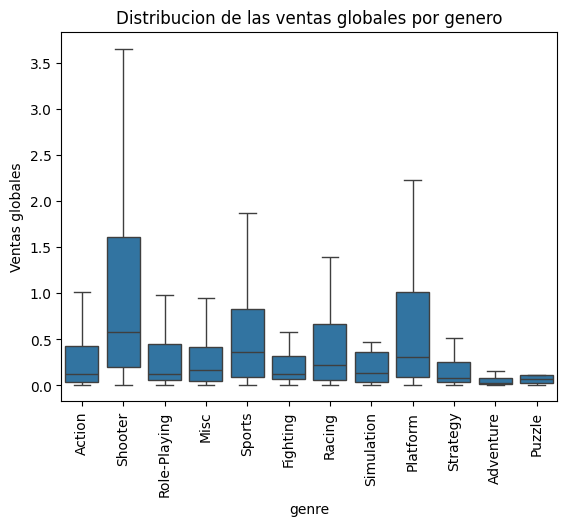

In [24]:
sns.boxplot(x = "genre", y = "total_sales", data = datos_necesarios , showfliers = False)
plt.xticks (rotation = 90)
plt.title("Distribucion de las ventas globales por genero")
plt.xlabel("genre")
plt.ylabel("Ventas globales")
plt.show()

In [25]:
resumen = datos_necesarios.groupby("genre")["total_sales"].agg(total_ventas ="sum", promedio="mean", mediana = "median", desviacion = "std", juegos = "count").sort_values("total_ventas", ascending = False)
print(resumen)

              total_ventas  promedio  mediana  desviacion  juegos
genre                                                            
Action              291.76  0.496190    0.130    1.411681     588
Shooter             194.76  1.391143    0.585    2.187639     140
Role-Playing        127.71  0.536597    0.130    1.421777     238
Sports              127.16  0.766024    0.365    1.226791     166
Misc                 60.22  0.489593    0.170    1.115217     123
Platform             39.40  0.667797    0.310    0.862009      59
Racing               37.10  0.608197    0.220    1.100926      61
Fighting             30.84  0.481875    0.130    1.156185      64
Simulation           19.87  0.451591    0.135    0.987838      44
Adventure            19.82  0.104868    0.030    0.233383     189
Strategy              8.95  0.208140    0.080    0.311496      43
Puzzle                3.16  0.197500    0.065    0.332536      16


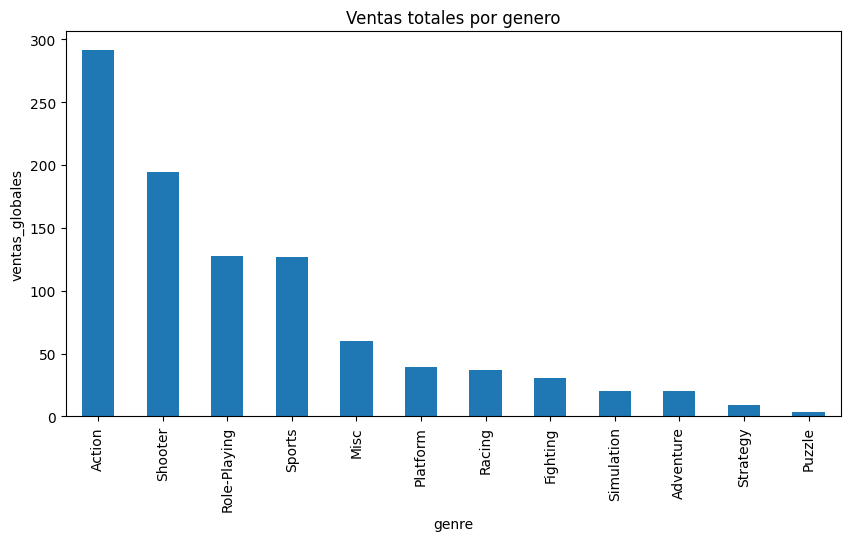

In [26]:
plt.figure(figsize = (10,5))
resumen["total_ventas"].sort_values(ascending =False).plot(kind = "bar")
plt.title("Ventas totales por genero")
plt.ylabel("ventas_globales")
plt.show()

con los ultimos dos graficos podemos ver que los generos mas rentables son shooter, action, role-playing y sports , ya que son los que concentran las mayores ventas totales y presentan medianas superiores al resto 

4 . PERFIL REGIONAL 

In [27]:
def perfil_regional (datos ,region):
    top_plataformas = datos.groupby("platform")[region].sum().sort_values(ascending = False).head(5)
    top_generos = datos.groupby("genre")[region].sum().sort_values(ascending = False).head(5)
    esrb = datos.groupby("rating")[region].mean().sort_values(ascending =False).head(5)
    return top_plataformas, top_generos, esrb
    

4 .1 PERFIL DE USUARIOS NA

In [28]:
datos_NA = perfil_regional(datos_necesarios, "na_sales")
print(datos_NA)

(platform
PS4     87.25
X360    80.97
XOne    78.85
PS3     62.83
3DS     34.06
Name: na_sales, dtype: float64, genre
Action          116.76
Shooter          93.50
Sports           57.73
Role-Playing     40.51
Misc             26.73
Name: na_sales, dtype: float64, rating
M             0.513883
E             0.301186
E10+          0.249653
T             0.165344
indefinido    0.107139
Name: na_sales, dtype: float64)


4 .2 PERFIL DE USUARIOS JP

In [29]:
datos_JP = perfil_regional (datos_necesarios, "jp_sales")
print(datos_JP)

(platform
3DS     59.78
PS3     22.05
PSV     15.03
PS4     10.22
WiiU    10.21
Name: jp_sales, dtype: float64, genre
Role-Playing    44.43
Action          33.42
Misc             8.16
Fighting         6.90
Shooter          5.55
Name: jp_sales, dtype: float64, rating
indefinido    0.093682
T             0.074170
E             0.059619
M             0.044364
E10+          0.026931
Name: jp_sales, dtype: float64)


4 .3 PERFIL DE USUARIOS EU

In [30]:
datos_EU = perfil_regional(datos_necesarios, "eu_sales")
print(datos_EU)

(platform
PS4     109.31
PS3      66.55
XOne     41.96
X360     41.81
3DS      28.63
Name: eu_sales, dtype: float64, genre
Action          107.45
Shooter          71.96
Sports           48.51
Role-Playing     32.69
Misc             19.38
Name: eu_sales, dtype: float64, rating
M             0.442543
E             0.295551
E10+          0.192475
T             0.130202
indefinido    0.094623
Name: eu_sales, dtype: float64)


5 . HIPOTESIS

5.1 HIPOTESIS 1 : Las calificaciones promedio de los usuarios son las mismas en la plataforma Xone y en PC

In [31]:
xone_score = datos_necesarios.loc[datos_necesarios["platform"] == "XOne", "user_score"].dropna()
pc_score = datos_necesarios.loc[datos_necesarios["platform"] == "PC", "user_score"].dropna()
alpha = 0.05
t_stat, p_value = stats.ttest_ind(xone_score, pc_score, equal_var = False)
print("t = ", t_stat)
print("p = ", p_value)
if p_value < alpha :
    print("Rechazamos H0 : Las medias de puntuacion de usuario de XOne son diferentes a los de PC" )
else :
    print("No rechazamoc H0 : no hay evidencia suficiente de diferencia en las medias")

t =  1.068235683729957
p =  0.2867036680187632
No rechazamoc H0 : no hay evidencia suficiente de diferencia en las medias


utilice una prueba una prueba t de dos muestras independientes , por que las dos plataformas tiene poblaciones diferentes , y elegi el umbral alpha de 0.05 por que es el estandar 

5.2 HIPOTESIS 2 : Las calificaciones promedio de los usuarios para los generos de accion y deportes son diferentes.

In [32]:
action_games = datos_necesarios.loc[datos_necesarios["genre"] == "Action", "user_score"].dropna()
sports_games = datos_necesarios.loc[datos_necesarios["genre"]== "Sports", "user_score"].dropna()
alpha = 0.05
t_stat, p_value = stats.ttest_ind(action_games, sports_games , equal_var = False )
print( "t = ", t_stat)
print( "p = ", p_value)

if p_value < alpha :
    print("Rechazamos H0 : Las medias de la puntuacion del usuario para los juegos de accion y deportes son diferentes ")
else :
    print ("No rechazamos H0 : No hay evidencia suficiente de que sean diferentes ")

t =  10.058038326676352
p =  3.507673706253342e-19
Rechazamos H0 : Las medias de la puntuacion del usuario para los juegos de accion y deportes son diferentes 


utilice una prueba una prueba t de dos muestras independientes , por que los dos generos tiene poblaciones diferentes , y elegi el umbral alpha de 0.05 por que es el estandar 

6 . CONCLUSION 

El analisis de mercado de los videojuegos muestra que las ventas dependen mucho de la plataforma, el genero y la region, los generos de action, shooter y sports conentran la mayor parte d elas ventas globales, las plataformas mas fuertes varian segun la region, en el occidente las mas fuertes son las de xbox one , xbox 360, ps3 y ps4, mientras que en japon domina nitendo, las reseñas d elos usuarios tienen poca relacion con las ventas, mientras que las reseñas de los criticos tienen una relacion moderada con las ventas, por ultimo las pruebas de hipotesis demuestran que algunas plataformas y generos presentan diferencias muy marcadas en sus puntuaciones promedio.